In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt

# Models & Domains

In [3]:
models = ['APHRO','GPCP','CRU','CHIRPS','HARv2','ERA5']
domains = ['HMA','HK','SL','TP','CH','SEH']

# TP timeseries DATASETS & DOMAINS

## Annual

In [5]:
tp_datasets = {}
stats_datasets = {}

periods = {'APHRO': '1951-2005',
          'GPCP': '1891-2019',
          'CRU': '1901-2020',
          'CHIRPS': '1981-2024',
          'HARv2': '1980-2023',
          'ERA5': '1960-2025'}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/'

for model in models:
    tp_datasets[model] = {}
    stats_datasets[model] = {}
    for domain in domains:
        tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_{periods[model]}_{model}.csv')
        stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_{periods[model]}_{model}.csv')

,HMA,HK,SL,TP,CH,SEH
APHRO,-0.26,-0.08,-2.23,-0.04,0.50,-1.08
GPCP,0.05,0.32,0.05,0.19,-0.66,-0.28
CRU,-0.04,0.60,-0.03,0.13,-0.84,-0.70
CHIRPS,1.19,0.86,1.53,1.10,0.66,0.66
HARv2,-0.13,-1.83,-0.80,1.13,3.50,-4.32
ERA5,-0.45,-0.47,-0.60,0.78,0.22,-3.89


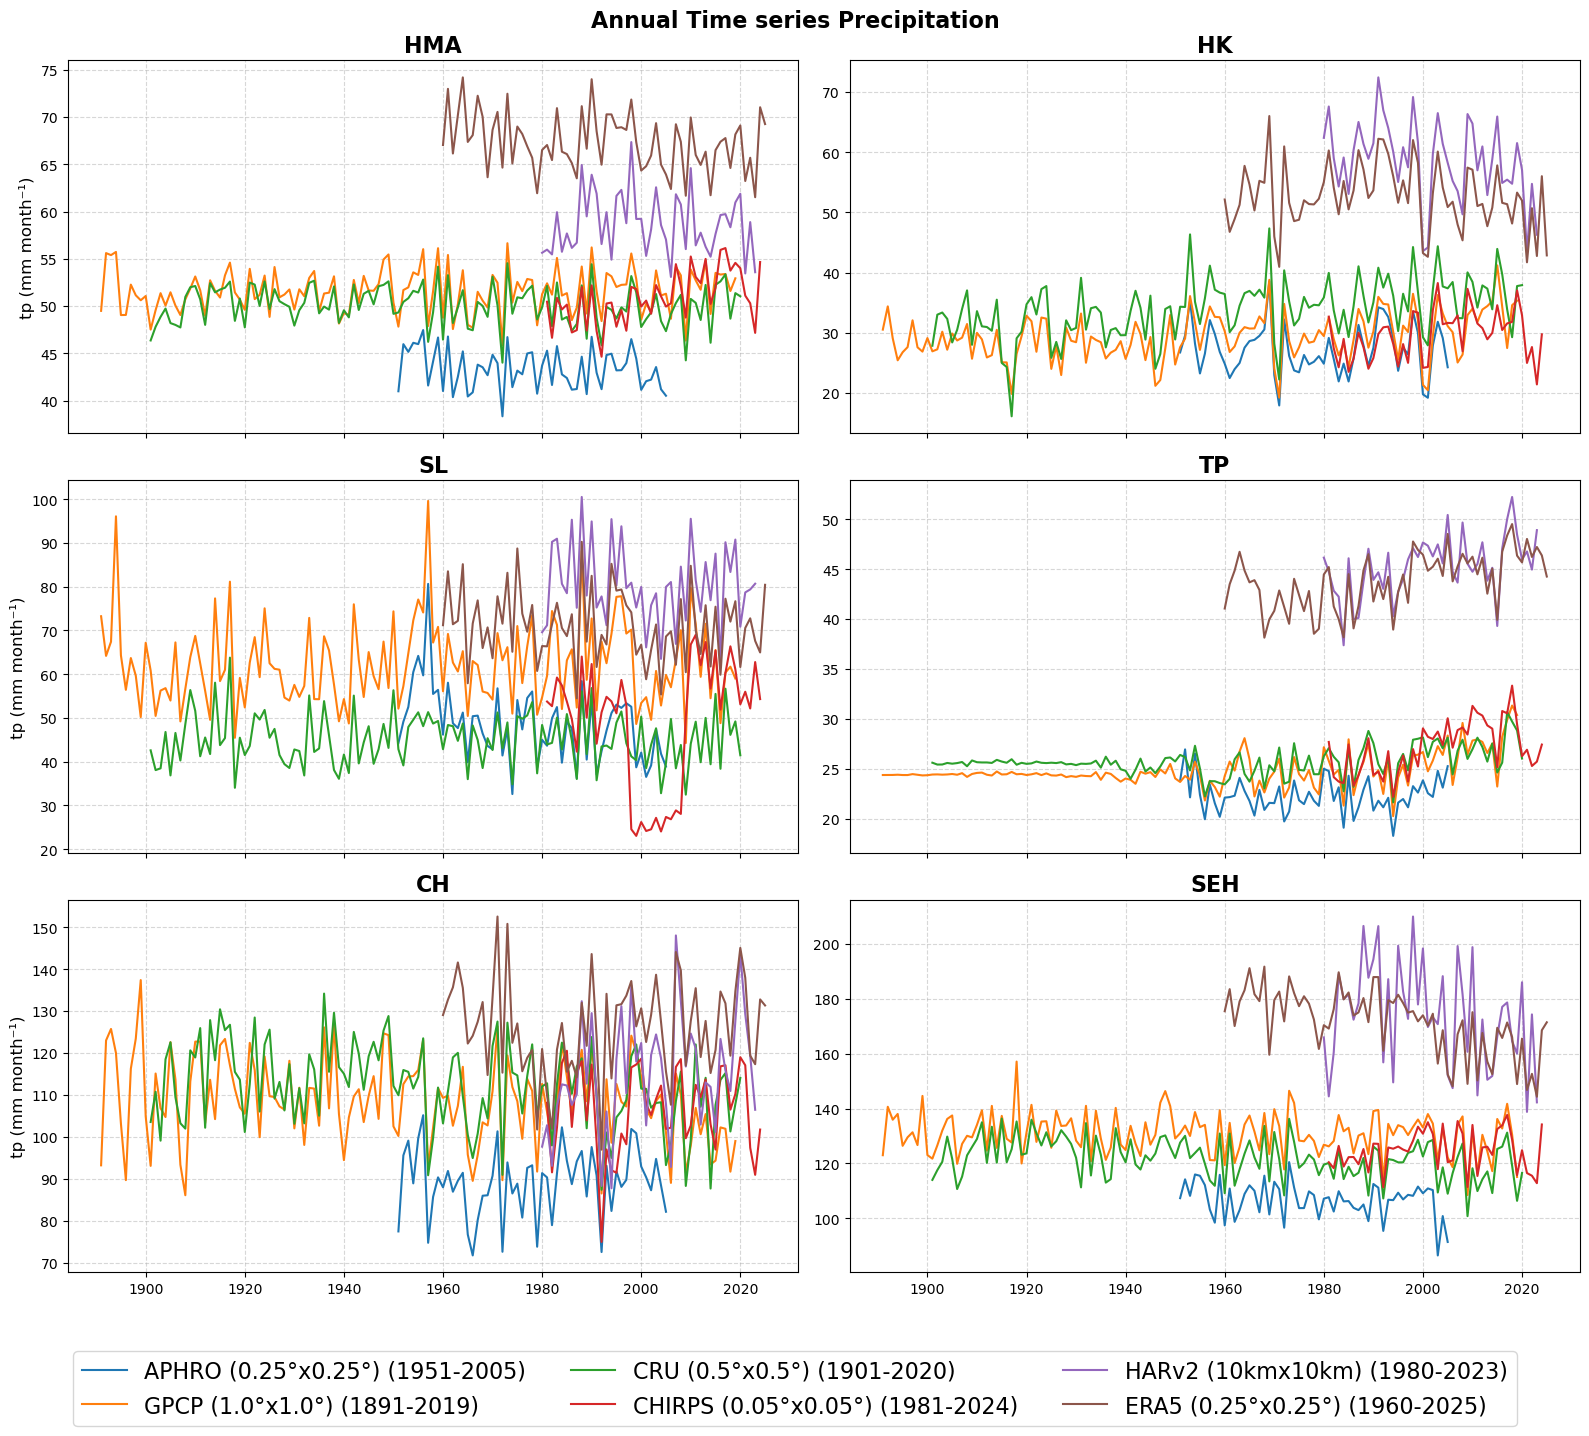

In [6]:
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}

#============== tableau des p-values ==========================

table = pd.DataFrame(index=models, columns=domains)
pvals = pd.DataFrame(index=models, columns=domains)

for model in models:
    for dom in domains:

        df = stats_datasets[model][dom]

        slope = df.loc[df['stat']=='slope','value'].values[0] * 10
        pval  = df.loc[df['stat']=='p_value','value'].values[0]

        table.loc[model, dom] = slope
        pvals.loc[model, dom] = pval

def bold_sig(val, p):
    if p < 0.05:
        return 'font-weight: bold'
    return ''

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format("{:.2f}")

display(styled_table)

# ====================== plot time series ========================

fig, axes = plt.subplots(3, 2, figsize=(16,14))
axes = axes.flatten()

for i, dom in enumerate(domains):

    ax = axes[i]

    for model in models:
        da = tp_datasets[model][dom]
        ax.plot(da['year'], da['tp'], linestyle='-', label=f'{model} ({resolutions[model]}) ({periods[model]})', linewidth=1.5)

    ax.set_title(dom, fontsize=16, weight="bold")
    
    if i in [0, 2, 4]:  # colonne gauche
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [4, 5]:  # ligne du bas
        ax.tick_params(labelbottom=True)
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'Annual Time series Precipitation', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

# DJFM

In [7]:
tp_datasets = {}
stats_datasets = {}

periods = {'APHRO': '1951-2005',
          'GPCP': '1891-2019',
          'CRU': '1901-2020',
          'CHIRPS': '1981-2024',
          'HARv2': '1980-2023',
          'ERA5': '1960-2025'}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/'

for model in models:
    tp_datasets[model] = {}
    stats_datasets[model] = {}
    for domain in domains:
        tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_DJFM_{domain}_{periods[model]}_{model}.csv')
        stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_DJFM_{domain}_{periods[model]}_{model}.csv')

,HMA,HK,SL,TP,CH,SEH
APHRO,0.03,-0.56,-2.01,-0.27,0.75,0.10
GPCP,0.02,0.34,-0.04,0.04,-0.22,-0.00
CRU,0.09,0.86,-0.22,0.03,-0.09,0.11
CHIRPS,0.04,0.04,-0.28,-0.10,-0.12,0.08
HARv2,-1.04,-4.35,-4.02,-0.19,-0.01,-2.98
ERA5,-0.27,-1.08,-0.60,0.07,0.37,-0.72


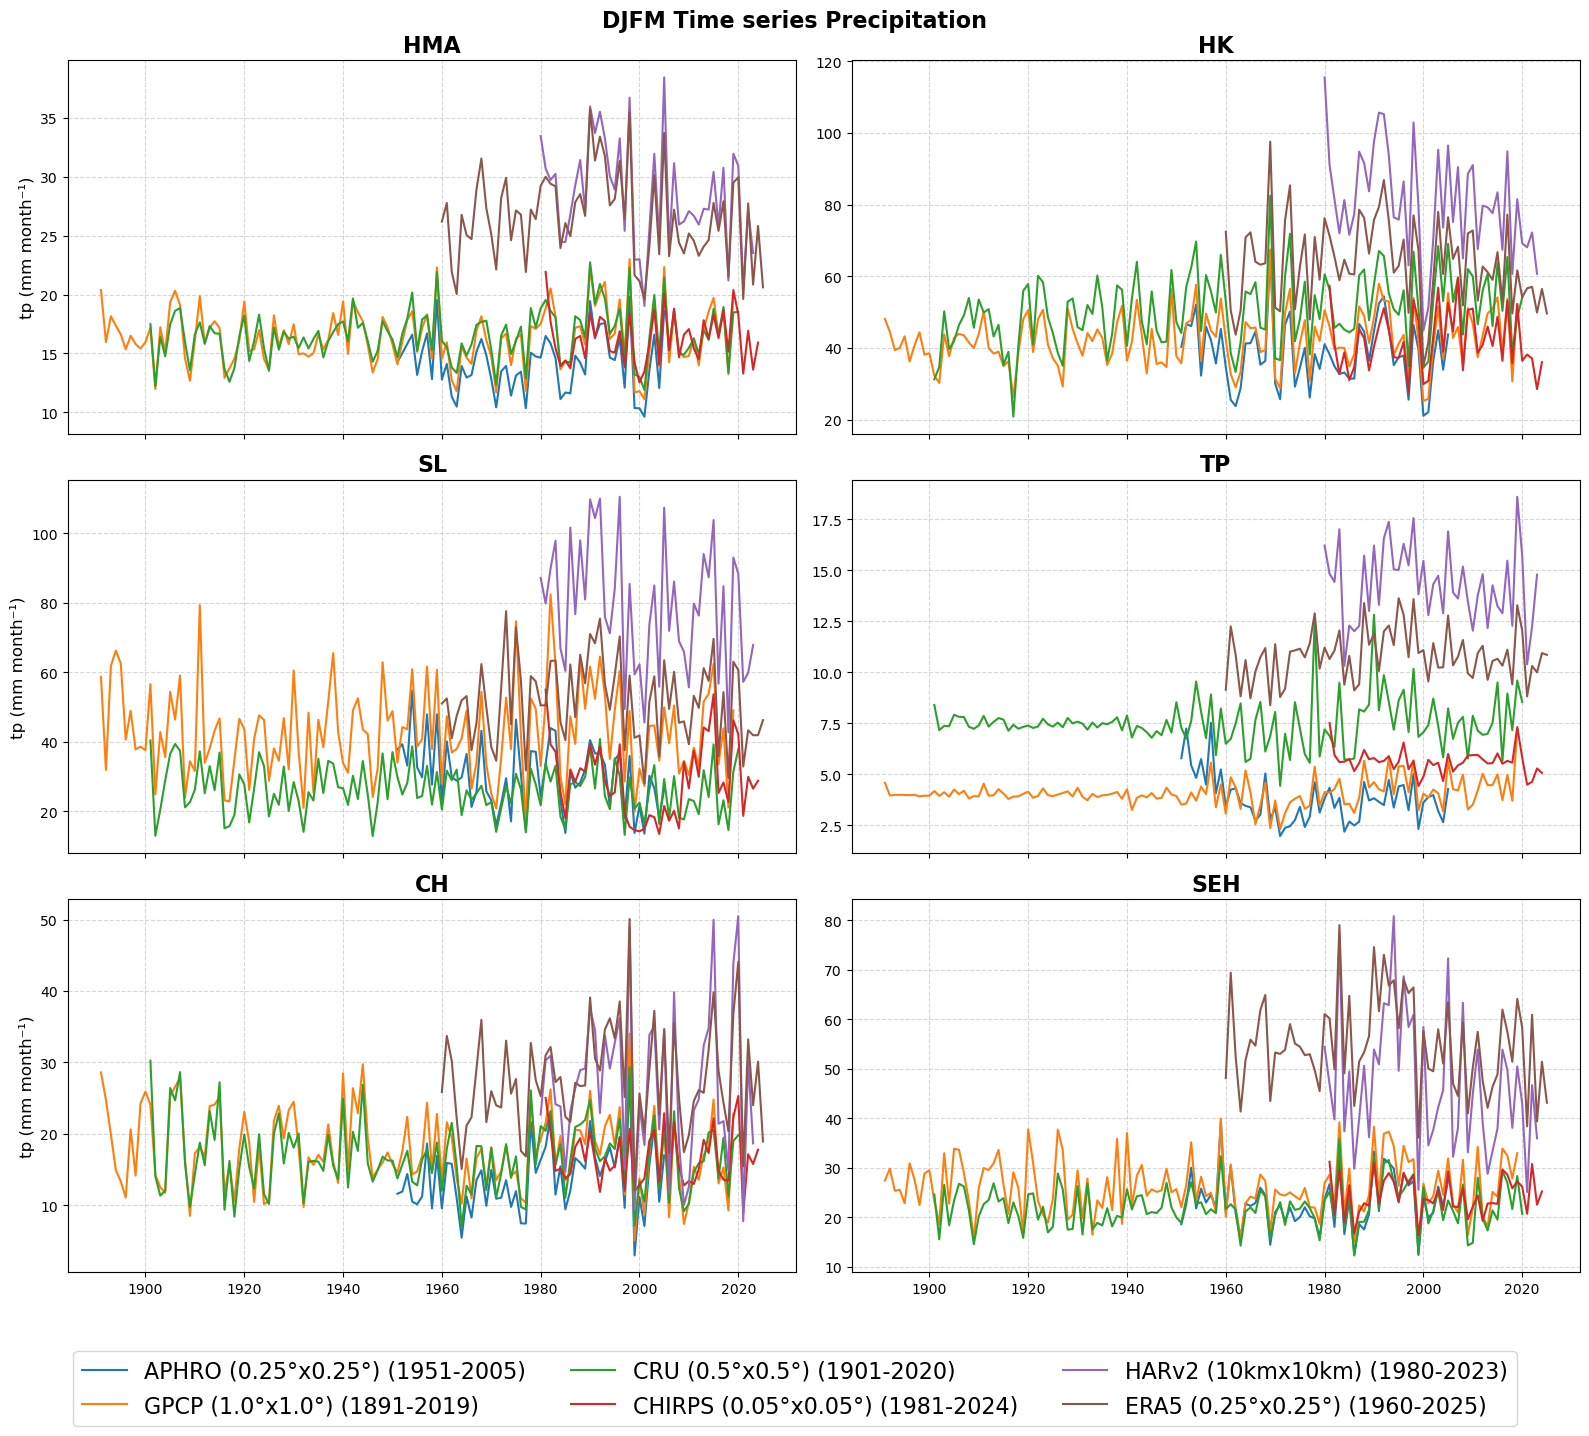

In [8]:
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}

#============== tableau des p-values ==========================

table = pd.DataFrame(index=models, columns=domains)
pvals = pd.DataFrame(index=models, columns=domains)

for model in models:
    for dom in domains:

        df = stats_datasets[model][dom]

        slope = df.loc[df['stat']=='slope','value'].values[0] * 10
        pval  = df.loc[df['stat']=='p_value','value'].values[0]

        table.loc[model, dom] = slope
        pvals.loc[model, dom] = pval

def bold_sig(val, p):
    if p < 0.05:
        return 'font-weight: bold'
    return ''

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format("{:.2f}")

display(styled_table)

# ====================== plot time series ========================

fig, axes = plt.subplots(3, 2, figsize=(16,14))
axes = axes.flatten()

for i, dom in enumerate(domains):

    ax = axes[i]

    for model in models:
        da = tp_datasets[model][dom]
        ax.plot(da['year'], da['tp'], linestyle='-', label=f'{model} ({resolutions[model]}) ({periods[model]})', linewidth=1.5)

    ax.set_title(dom, fontsize=16, weight="bold")
    
    if i in [0, 2, 4]:  # colonne gauche
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [4, 5]:  # ligne du bas
        ax.tick_params(labelbottom=True)
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'DJFM Time series Precipitation', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

# AM

In [9]:
tp_datasets = {}
stats_datasets = {}

periods = {'APHRO': '1951-2005',
          'GPCP': '1891-2019',
          'CRU': '1901-2020',
          'CHIRPS': '1981-2024',
          'HARv2': '1980-2023',
          'ERA5': '1960-2025'}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/'

for model in models:
    tp_datasets[model] = {}
    stats_datasets[model] = {}
    for domain in domains:
        tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_AM_{domain}_{periods[model]}_{model}.csv')
        stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_AM_{domain}_{periods[model]}_{model}.csv')

,HMA,HK,SL,TP,CH,SEH
APHRO,0.16,-1.27,-0.23,0.34,3.16,-0.48
GPCP,0.19,0.41,0.39,0.31,-0.10,0.16
CRU,0.10,0.65,0.64,0.28,0.70,-0.86
CHIRPS,0.98,2.39,1.77,1.08,0.84,0.29
HARv2,-0.29,-1.43,-5.29,1.65,1.92,-4.11
ERA5,-0.50,-2.96,-0.48,1.10,2.98,-3.54


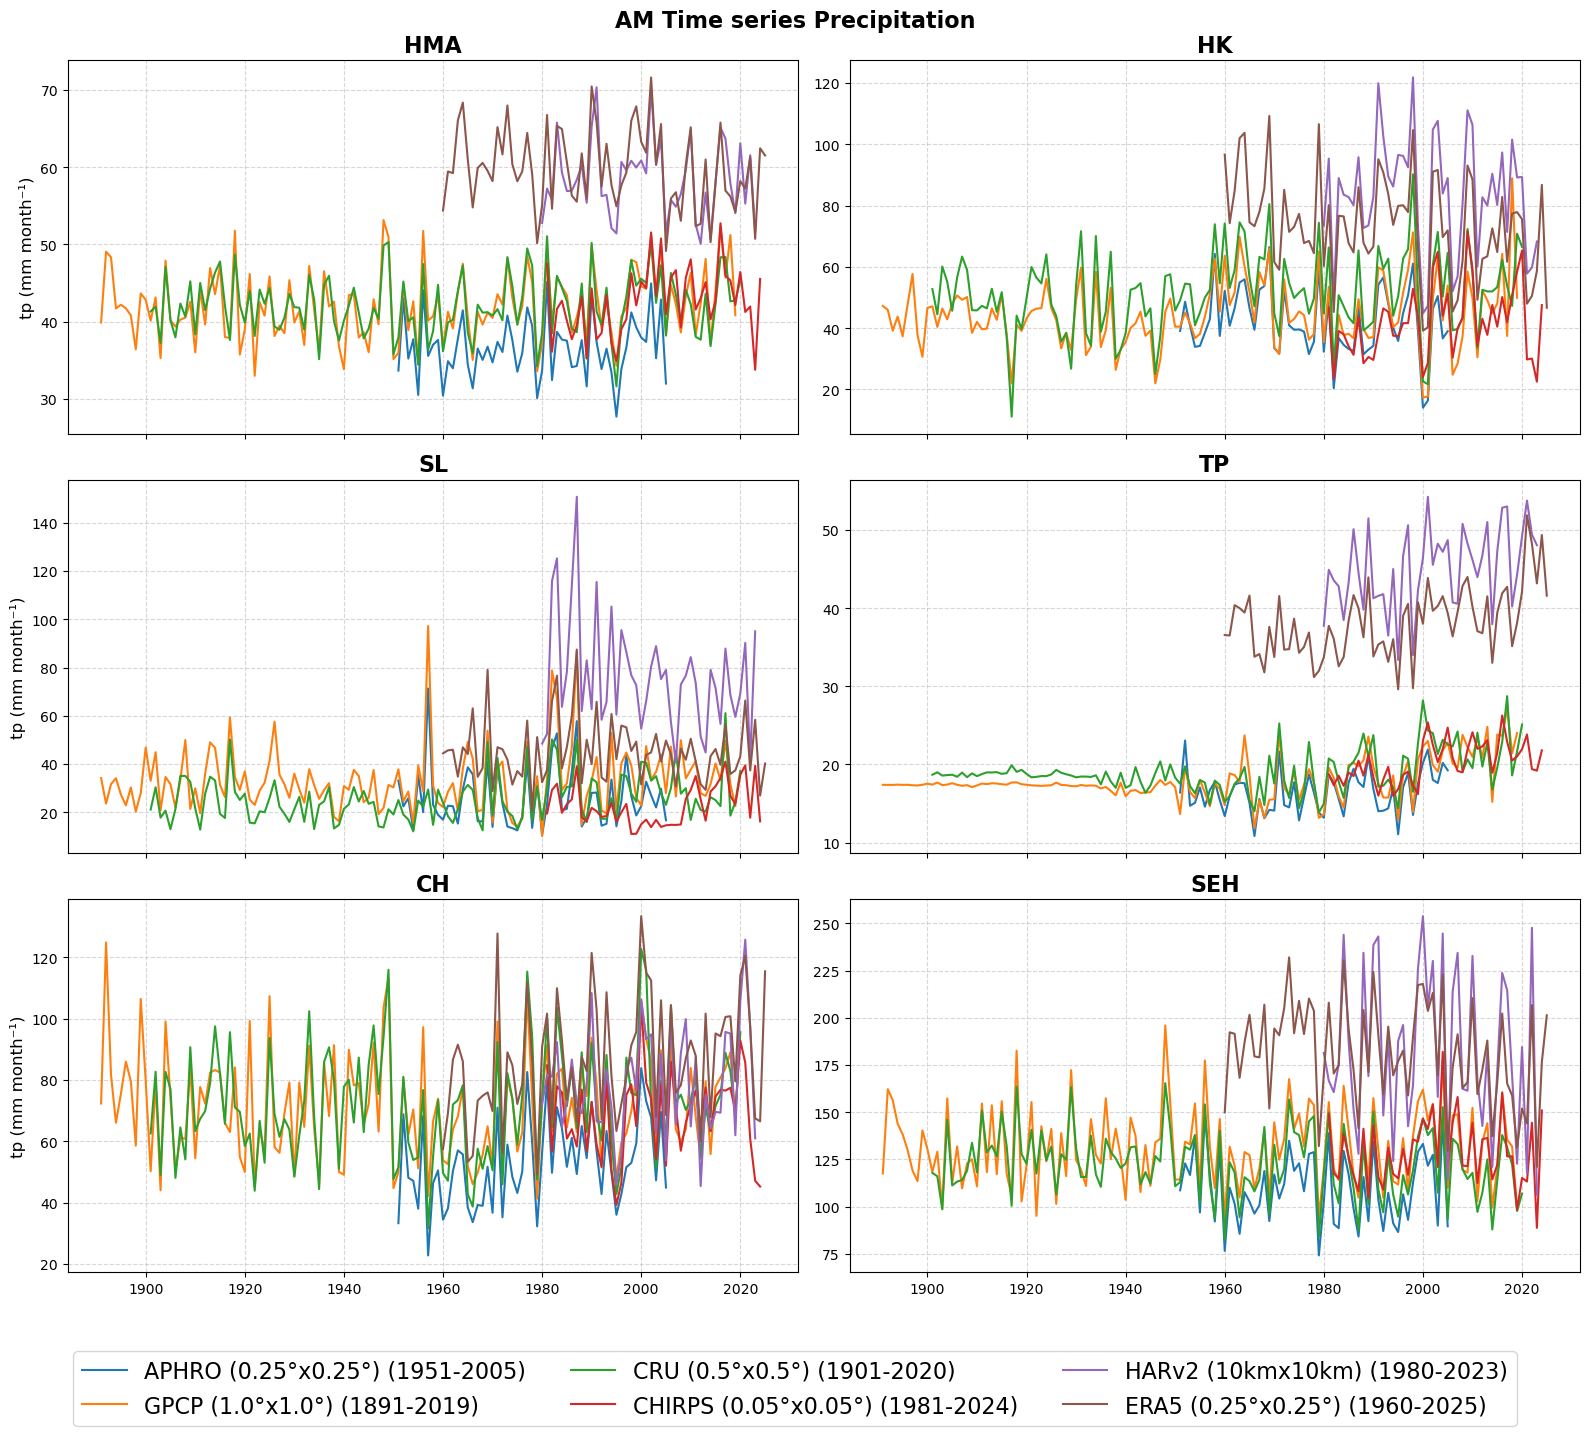

In [10]:
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}

#============== tableau des p-values ==========================

table = pd.DataFrame(index=models, columns=domains)
pvals = pd.DataFrame(index=models, columns=domains)

for model in models:
    for dom in domains:

        df = stats_datasets[model][dom]

        slope = df.loc[df['stat']=='slope','value'].values[0] * 10
        pval  = df.loc[df['stat']=='p_value','value'].values[0]

        table.loc[model, dom] = slope
        pvals.loc[model, dom] = pval

def bold_sig(val, p):
    if p < 0.05:
        return 'font-weight: bold'
    return ''

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format("{:.2f}")

display(styled_table)

# ====================== plot time series ========================

fig, axes = plt.subplots(3, 2, figsize=(16,14))
axes = axes.flatten()

for i, dom in enumerate(domains):

    ax = axes[i]

    for model in models:
        da = tp_datasets[model][dom]
        ax.plot(da['year'], da['tp'], linestyle='-', label=f'{model} ({resolutions[model]}) ({periods[model]})', linewidth=1.5)

    ax.set_title(dom, fontsize=16, weight="bold")
    
    if i in [0, 2, 4]:  # colonne gauche
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [4, 5]:  # ligne du bas
        ax.tick_params(labelbottom=True)
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'AM Time series Precipitation', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

# JJAS

In [11]:
tp_datasets = {}
stats_datasets = {}

periods = {'APHRO': '1951-2005',
          'GPCP': '1891-2019',
          'CRU': '1901-2020',
          'CHIRPS': '1981-2024',
          'HARv2': '1980-2023',
          'ERA5': '1960-2025'}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/'

for model in models:
    tp_datasets[model] = {}
    stats_datasets[model] = {}
    for domain in domains:
        tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_JJAS_{domain}_{periods[model]}_{model}.csv')
        stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_JJAS_{domain}_{periods[model]}_{model}.csv')

,HMA,HK,SL,TP,CH,SEH
APHRO,-0.65,1.03,-3.32,0.10,-0.81,-2.15
GPCP,-0.00,0.14,-0.22,0.34,-1.61,-0.60
CRU,-0.29,0.25,-0.29,0.22,-2.87,-1.48
CHIRPS,2.60,0.43,3.59,2.62,0.44,1.92
HARv2,0.58,-0.97,3.57,2.27,7.51,-6.65
ERA5,-0.70,0.90,-1.18,1.51,-1.75,-7.10


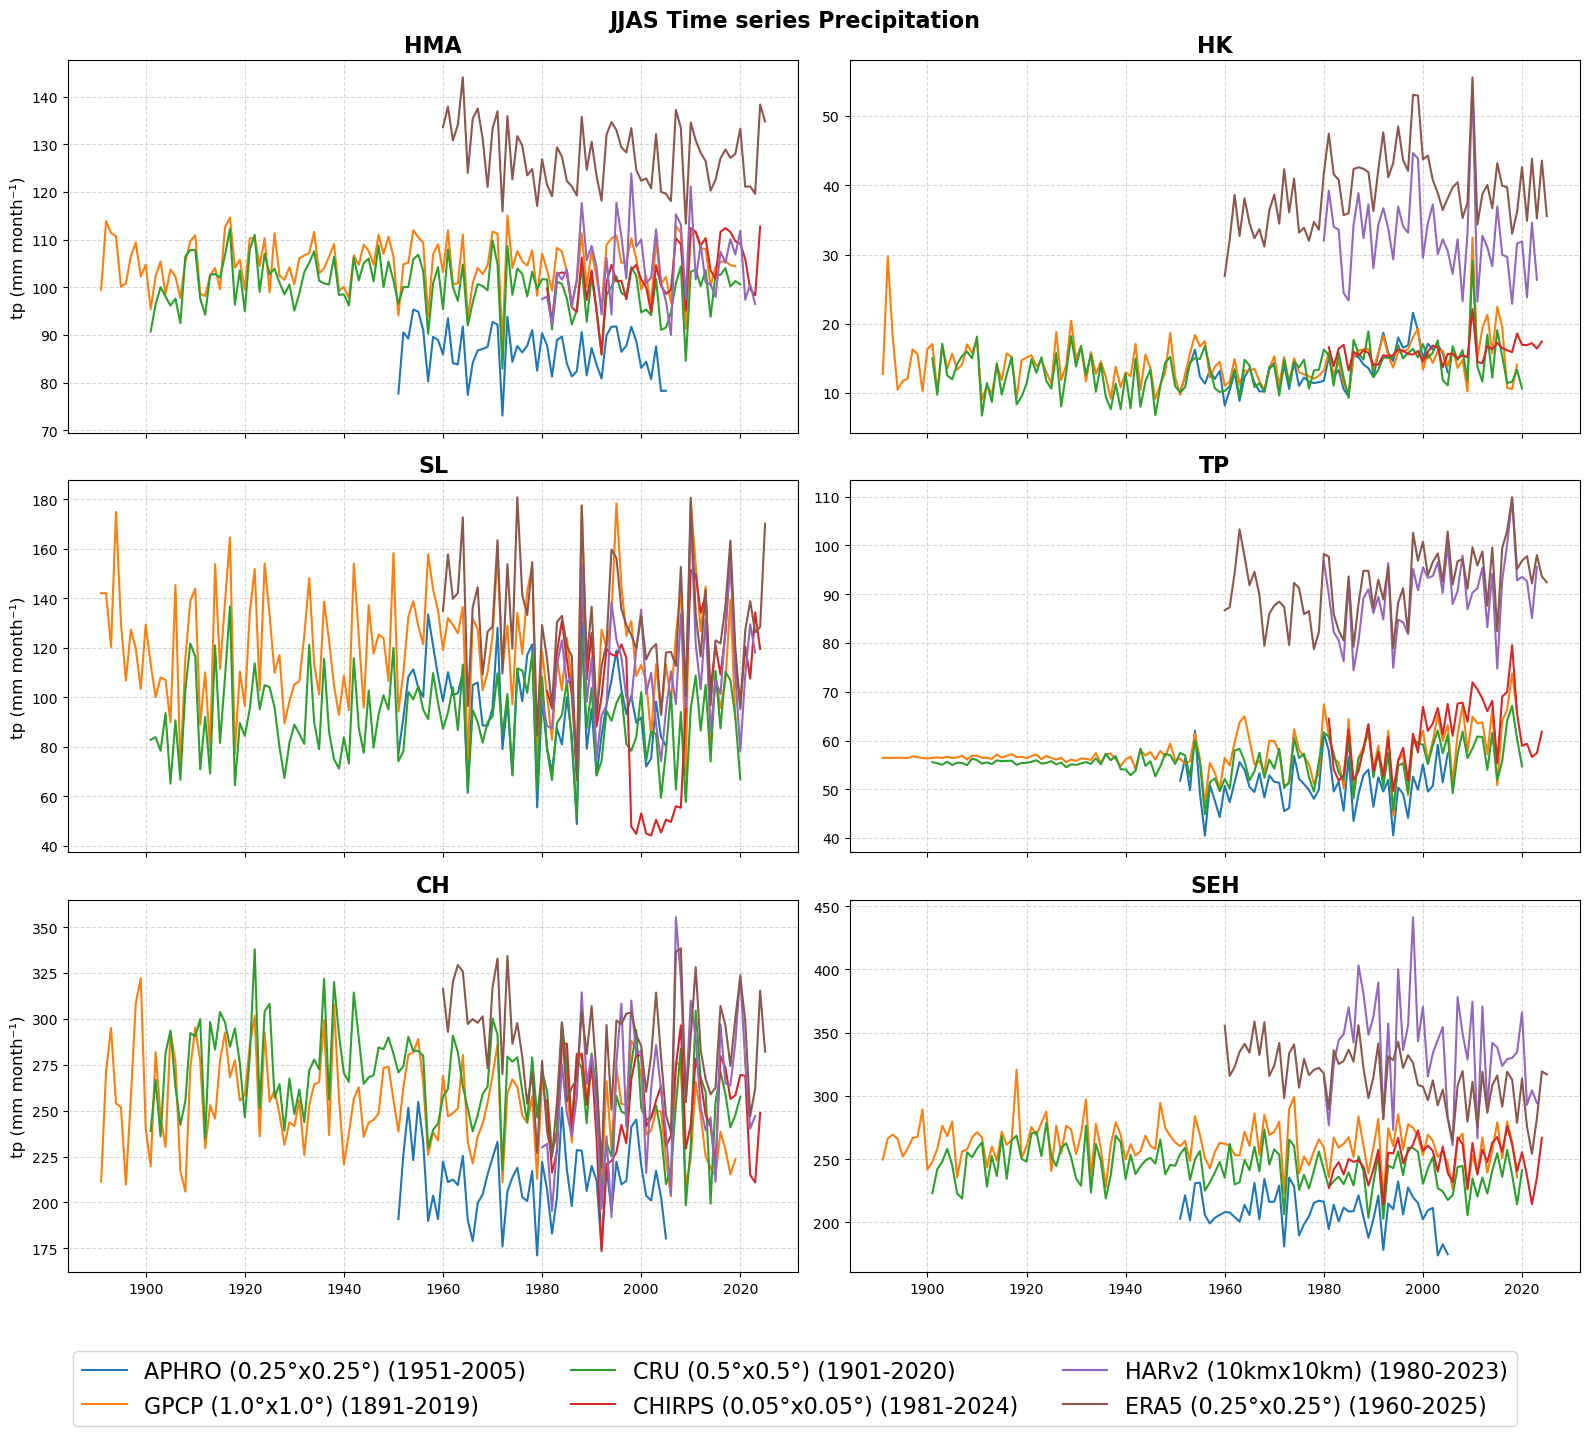

In [12]:
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}

#============== tableau des p-values ==========================

table = pd.DataFrame(index=models, columns=domains)
pvals = pd.DataFrame(index=models, columns=domains)

for model in models:
    for dom in domains:

        df = stats_datasets[model][dom]

        slope = df.loc[df['stat']=='slope','value'].values[0] * 10
        pval  = df.loc[df['stat']=='p_value','value'].values[0]

        table.loc[model, dom] = slope
        pvals.loc[model, dom] = pval

def bold_sig(val, p):
    if p < 0.05:
        return 'font-weight: bold'
    return ''

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format("{:.2f}")

display(styled_table)

# ====================== plot time series ========================

fig, axes = plt.subplots(3, 2, figsize=(16,14))
axes = axes.flatten()

for i, dom in enumerate(domains):

    ax = axes[i]

    for model in models:
        da = tp_datasets[model][dom]
        ax.plot(da['year'], da['tp'], linestyle='-', label=f'{model} ({resolutions[model]}) ({periods[model]})', linewidth=1.5)

    ax.set_title(dom, fontsize=16, weight="bold")
    
    if i in [0, 2, 4]:  # colonne gauche
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [4, 5]:  # ligne du bas
        ax.tick_params(labelbottom=True)
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'JJAS Time series Precipitation', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

# ON

In [13]:
tp_datasets = {}
stats_datasets = {}

periods = {'APHRO': '1951-2005',
          'GPCP': '1891-2019',
          'CRU': '1901-2020',
          'CHIRPS': '1981-2024',
          'HARv2': '1980-2023',
          'ERA5': '1960-2025'}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/'

for model in models:
    tp_datasets[model] = {}
    stats_datasets[model] = {}
    for domain in domains:
        tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_ON_{domain}_{periods[model]}_{model}.csv')
        stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_ON_{domain}_{periods[model]}_{model}.csv')

,HMA,HK,SL,TP,CH,SEH
APHRO,-0.49,-0.13,-2.64,-0.28,-0.06,-1.97
GPCP,0.05,0.56,0.33,0.07,-0.24,-0.67
CRU,0.06,0.72,0.16,0.02,0.12,-0.56
CHIRPS,0.72,1.62,0.15,0.41,2.23,-0.56
HARv2,0.29,0.63,1.26,0.87,3.99,-3.10
ERA5,-0.33,0.16,0.39,0.43,1.11,-4.11


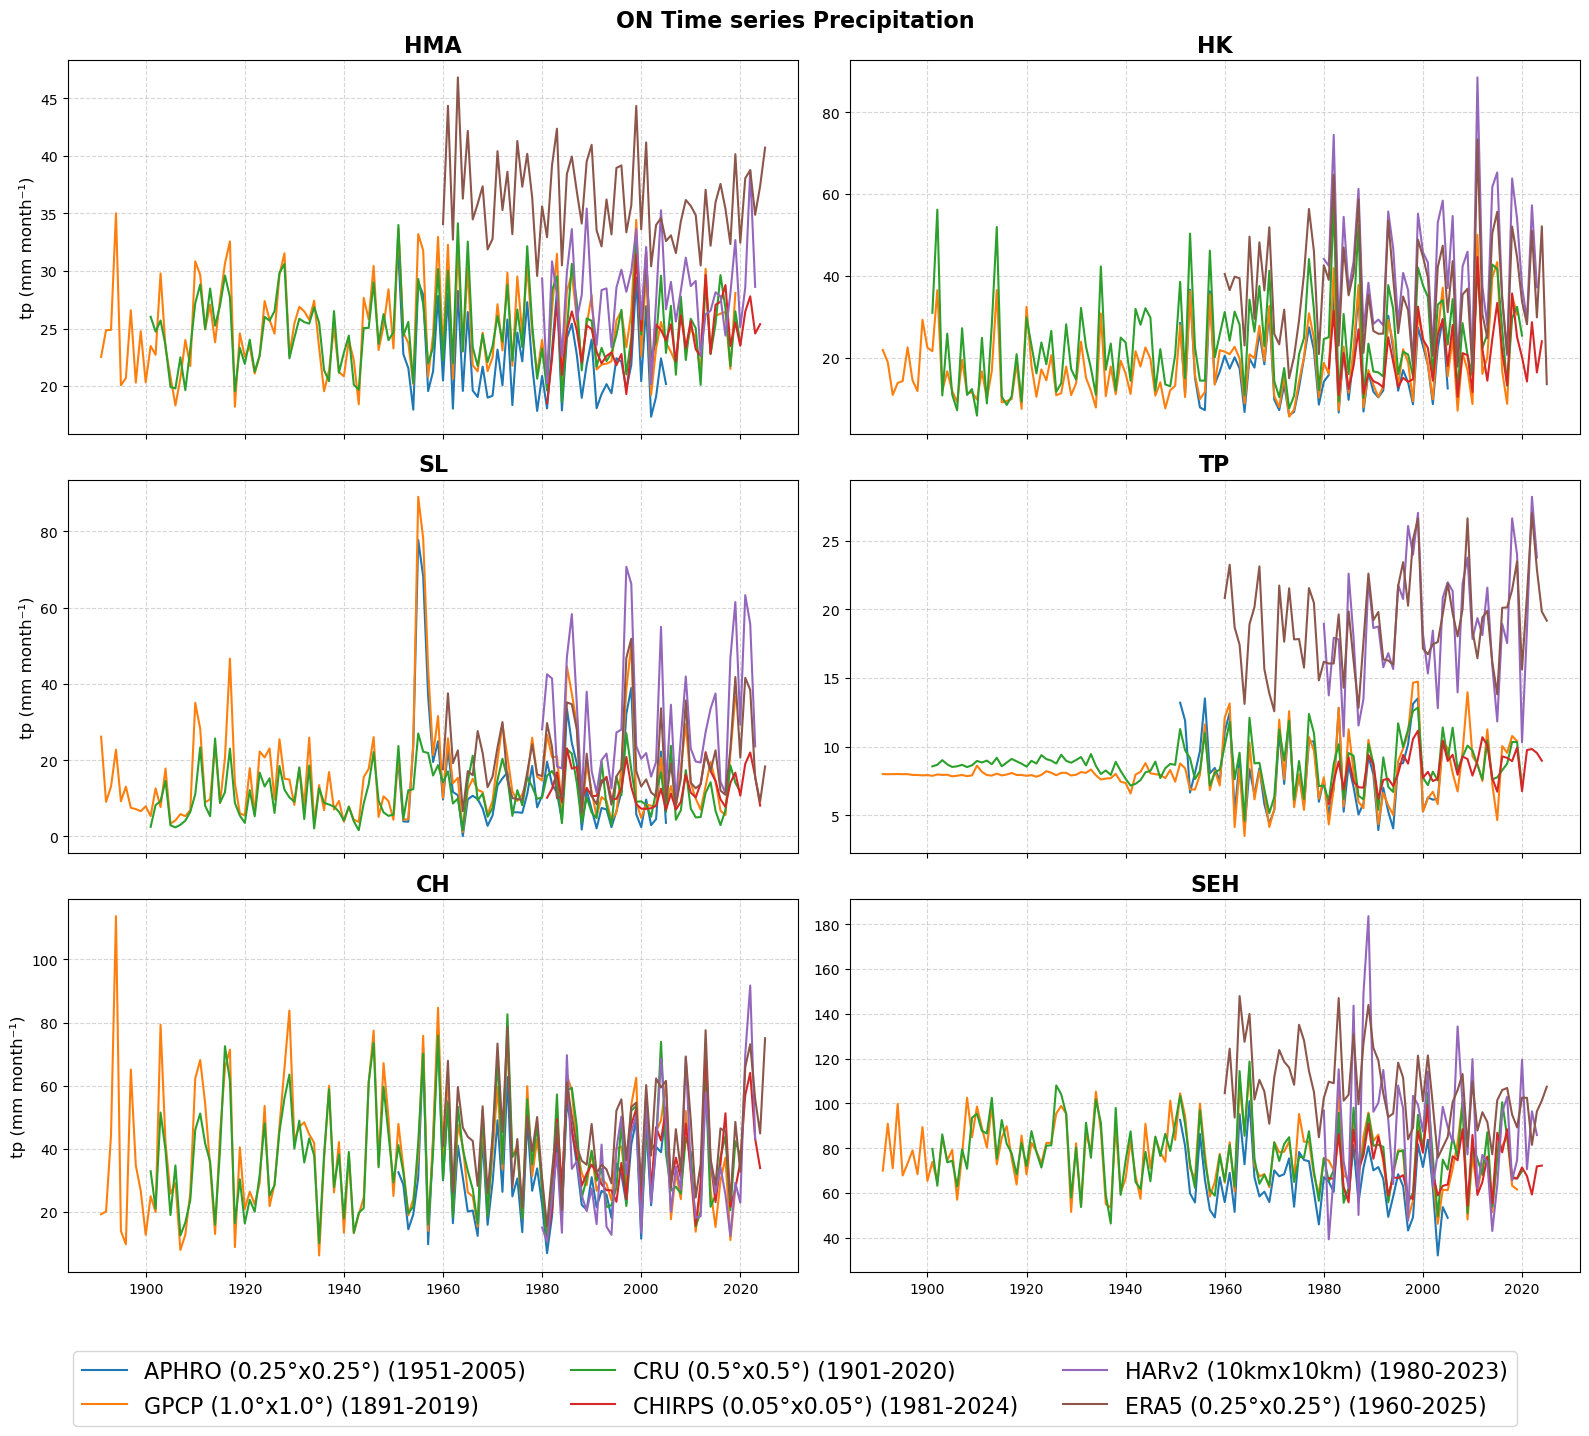

In [14]:
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}

#============== tableau des p-values ==========================

table = pd.DataFrame(index=models, columns=domains)
pvals = pd.DataFrame(index=models, columns=domains)

for model in models:
    for dom in domains:

        df = stats_datasets[model][dom]

        slope = df.loc[df['stat']=='slope','value'].values[0] * 10
        pval  = df.loc[df['stat']=='p_value','value'].values[0]

        table.loc[model, dom] = slope
        pvals.loc[model, dom] = pval

def bold_sig(val, p):
    if p < 0.05:
        return 'font-weight: bold'
    return ''

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format("{:.2f}")

display(styled_table)

# ====================== plot time series ========================

fig, axes = plt.subplots(3, 2, figsize=(16,14))
axes = axes.flatten()

for i, dom in enumerate(domains):

    ax = axes[i]

    for model in models:
        da = tp_datasets[model][dom]
        ax.plot(da['year'], da['tp'], linestyle='-', label=f'{model} ({resolutions[model]}) ({periods[model]})', linewidth=1.5)

    ax.set_title(dom, fontsize=16, weight="bold")
    
    if i in [0, 2, 4]:  # colonne gauche
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [4, 5]:  # ligne du bas
        ax.tick_params(labelbottom=True)
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'ON Time series Precipitation', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()